In [86]:
import numpy as np
from pymdp.agent import Agent

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io
import imageio
from itertools import product
import random
from IPython.display import Image, display

# reproducibility
random.seed(42)
np.random.seed(1)

In [87]:
# BLOCK 1: Build arena mask + mappings (modular arena)
# You can change rows, cols, and corridor params below to create different arenas.

def make_two_rooms_with_corridor(rows=3, left_cols=2, corridor_cols=3, right_cols=2,
                                 corridor_rows=(1),  # tuple/list of row indices that ARE passable in corridor
                                 prefer_total_cols=None):
    """
    Construct a boolean mask for two square rooms (left, right) connected by a corridor.
    Returns mask (rows x total_cols) with True for passable cells and False for blocked.
    corridor_rows: which rows (0-indexed) in the corridor region are allowed to be passable.
                   e.g., (1,2) for two middle rows in a 4-row grid.
    prefer_total_cols: if you need a target total width (e.g. 10), you can supply it and
                       function will try to center corridor; if None, uses left+corridor+right.
    """
    # compute total_cols
    default_total = left_cols + corridor_cols + right_cols
    if prefer_total_cols is None:
        total_cols = default_total
    else:
        total_cols = prefer_total_cols
        # If prefer_total_cols differs from default, we will embed the three regions appropriately
        # We'll place left at col 0, corridor after left, and right at the end so overall fits.
    mask = np.zeros((rows, total_cols), dtype=bool)

    # left room: columns 0 .. left_cols-1 (all rows)
    left_start = 0
    left_end = left_start + left_cols  # exclusive
    mask[:, left_start:left_end] = True

    # corridor: place immediately after left
    corridor_start = left_end
    corridor_end = corridor_start + corridor_cols
    if corridor_end > total_cols:
        raise ValueError("Corridor doesn't fit in prefer_total_cols; increase total width or reduce corridor width.")
    # corridor rows: only allow rows in corridor_rows list (e.g., middle rows)
    for r in corridor_rows:
        mask[r, corridor_start:corridor_end] = True

    # right room: place at the end to make total width sensible
    right_end = total_cols
    right_start = right_end - right_cols
    mask[:, right_start:right_end] = True

    return mask, {"left": (slice(None), slice(left_start, left_end)),
                  "corridor": (slice(None), slice(corridor_start, corridor_end)),
                  "right": (slice(None), slice(right_start, right_end))}

# "T" maze with the perpendicular arm on the right
rows = 4
left_cols = 0
corridor_cols = 3   # corridor width
right_cols = 2
corridor_rows = (1,2)  # allow rows 1 and 2 (middle two rows), top(0) and bottom(3) are blocked in corridor
mask, regions = make_two_rooms_with_corridor(rows=rows, left_cols=left_cols,
                                             corridor_cols=corridor_cols, right_cols=right_cols,
                                             corridor_rows=corridor_rows, prefer_total_cols=None)

print("Arena mask shape:", mask.shape)
print("Passable cells count:", mask.sum())


Arena mask shape: (4, 5)
Passable cells count: 14


In [88]:
# BLOCK 2: Compact mapping from (r,c) -> state index and back for only passable cells


rows, cols = mask.shape
# create list of valid (r,c) and mapping arrays
valid_rc = [(r, c) for r in range(rows) for c in range(cols) if mask[r, c]]
n_states = len(valid_rc)


# observation modalities -> threat intensity/dist, shelter, agent location
n_threat_obs = 4                         # intensities 0..3 with higher intensity is closer => can make this modular in the future
n_shelter_obs = 2 # [NOT AT, AT]
n_agent_obs = n_states

actions = ["up", "down", "left", "right", "stay"]
n_actions = len(actions)

# maps: rc -> compact state id (0..n_states-1), and state->(r,c)
rc_to_state = -np.ones((rows, cols), dtype=int)   # -1 for blocked cells
state_to_rc = [None] * n_states
for i, (r, c) in enumerate(valid_rc):
    rc_to_state[r, c] = i
    state_to_rc[i] = (r, c)

def state_idx_to_rc(idx):
    return state_to_rc[int(idx)]

def rc_to_state_idx(r, c):
    return int(rc_to_state[r, c])

print("n_states (valid cells):", n_states)
print("Sample mapping: first 6 states -> rc:", state_to_rc[:6])


n_states (valid cells): 14
Sample mapping: first 6 states -> rc: [(0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3)]


In [89]:
# BLOCK 3: step_from using neighbor adjacency on masked arena
# actions defined as before: 0=up,1=down,2=left,3=right,4=stay

def step_from_state(state_idx, action):
    r, c = state_idx_to_rc(state_idx)
    if action == 0:   # up
        nr, nc = r - 1, c
    elif action == 1: # down
        nr, nc = r + 1, c
    elif action == 2: # left
        nr, nc = r, c - 1
    elif action == 3: # right
        nr, nc = r, c + 1
    elif action == 4: # stay
        nr, nc = r, c
    else:
        raise ValueError("bad action")

    # If target is outside bounds or blocked, stay in place
    if nr < 0 or nr >= rows or nc < 0 or nc >= cols:
        return state_idx
    if not mask[nr, nc]:
        return state_idx
    return rc_to_state_idx(nr, nc)

# Example sanity checks
for i in range(min(6, n_states)):
    r,c = state_idx_to_rc(i)
    print("state", i, "rc", (r,c), "neighbors:", [step_from_state(i,a) for a in range(len(actions))])


state 0 rc (0, 3) neighbors: [0, 5, 0, 1, 0]
state 1 rc (0, 4) neighbors: [1, 6, 0, 1, 1]
state 2 rc (1, 0) neighbors: [2, 7, 2, 3, 2]
state 3 rc (1, 1) neighbors: [3, 8, 2, 4, 3]
state 4 rc (1, 2) neighbors: [4, 9, 3, 5, 4]
state 5 rc (1, 3) neighbors: [0, 10, 4, 6, 5]


In [90]:
# BLOCK 4: Build B (object array) using n_states and the new step_from_state function

n_agent = n_states
n_threat = n_states
n_shelter = n_states

n_controls_agent = n_actions
n_controls_threat = 1
n_controls_shelter = 1

# build B_agent: shape (S_next, S_current, n_controls_agent)
B_agent = np.zeros((n_agent, n_agent, n_controls_agent), dtype=float)

for s in range(n_agent):
    for a in range(n_actions):
        ns = step_from_state(s, a)
        # make deterministic-ish with tiny exploration noise
        B_agent[ns, s, a] += 0.99
        # distribute small noise among other reachable neighbors (including stay)
        # find reachable neighbors from s
        neighbors = set(step_from_state(s, aa) for aa in range(n_actions))
        neighbors = sorted(neighbors)
        # distribute 0.01 equally (excluding ns since we already gave 0.99)
        residue = 0.01
        for nb in neighbors:
            if nb == ns:
                continue
            B_agent[nb, s, a] += residue / max(1, (len(neighbors)-1))

# normalize columns for numerical safety
for a in range(n_controls_agent):
    col_sums = B_agent[:, :, a].sum(axis=0)
    # if some column sums slightly != 1 due to rounding, normalize
    for s in range(n_agent):
        if col_sums[s] <= 0:
            B_agent[:, s, a] = 1.0 / n_agent
        else:
            B_agent[:, s, a] /= col_sums[s]

# B for static threat and shelter (identity)
B_threat = np.zeros((n_threat, n_threat, n_controls_threat))
for s in range(n_threat):
    B_threat[s, s, 0] = 1.0

B_shelter = np.zeros((n_shelter, n_shelter, n_controls_shelter))
for s in range(n_shelter):
    B_shelter[s, s, 0] = 1.0

# pack into object array B
B = np.empty(3, dtype=object)
B[0] = B_agent
B[1] = B_threat
B[2] = B_shelter

print("Built B with shapes:")
print(" B_agent:", B_agent.shape, "n_states:", n_agent)


Built B with shapes:
 B_agent: (14, 14, 5) n_states: 14


In [91]:
# BLOCK 5: Build A modalities using compact state indices but compute manhattan in rc-space.
# This mirrors your earlier construction but iterates only over valid states.

# helper: compute manhattan distance using rc positions
def manhattan_states(s1, s2):
    r1, c1 = state_idx_to_rc(s1)
    r2, c2 = state_idx_to_rc(s2)
    return abs(r1 - r2) + abs(c1 - c2)

# observation sizes
n_threat_obs = 4
n_shelter_obs = 5
n_agent_obs = n_agent  # identity proprioception

A_threat = np.zeros((n_threat_obs, n_agent, n_threat, n_shelter))
for a in range(n_agent):
    for t in range(n_threat):
        for s in range(n_shelter):
            d = manhattan_states(a, t)
            # using same mapping as before but with more flexible arena
            if d == 0:
                A_threat[3, a, t, s] = 1.0
                # A_threat[2, a, t, s] = 0.25
            elif d == 1:
                A_threat[2, a, t, s] = 0.75
                A_threat[1, a, t, s] = 0.25
            elif d == 2:
                A_threat[1, a, t, s] = 0.75
                A_threat[0, a, t, s] = 0.25
            else:
                A_threat[0, a, t, s] = 1.0
A_threat /= A_threat.sum(axis=0, keepdims=True)

# shelter modality (is agent at shelter index?)
A_shelter = np.zeros((n_shelter_obs, n_agent, n_threat, n_shelter))
for a in range(n_agent):
    for t in range(n_threat):
        for s in range(n_shelter):
            d = manhattan_states(a, s)
            if d == 0:
                A_shelter[4, a, t, s] = 1.0
            elif d == 1:
                A_shelter[3, a, t, s] = 0.8
                A_shelter[2, a, t, s] = 0.2
            elif d == 2:
                A_shelter[2, a, t, s] = 0.95
                A_shelter[1, a, t, s] = 0.05
            elif d == 3:
                A_shelter[1, a, t, s] = 1.0
            else:
                A_shelter[0, a, t, s] = 1.0
A_shelter /= A_shelter.sum(axis=0, keepdims=True)

# agent proprioception: one-hot on compact index
A_agent = np.zeros((n_agent_obs, n_agent, n_threat, n_shelter))
for a in range(n_agent):
    A_agent[a, a, :, :] = 1.0
    # small uniform noise for others
    # A_agent[:, a, :, :] += (0.05 / (n_agent_obs - 1))
A_agent /= A_agent.sum(axis=0, keepdims=True)

# pack into object array
A = np.empty(3, dtype=object)
A[0] = A_threat
A[1] = A_shelter
A[2] = A_agent

print("Built A with shapes:", [A[i].shape for i in range(3)])


Built A with shapes: [(4, 14, 14, 14), (5, 14, 14, 14), (14, 14, 14, 14)]


In [92]:
# BLOCK 6 (REPLACEMENT): D priors — agent & threat uniform over whole arena; shelter prior = leftmost column

# helper: collect valid states in a column index
def collect_states_in_column(col_idx):
    states = []
    for r in range(rows):
        if 0 <= col_idx < cols and mask[r, col_idx]:
            states.append(rc_to_state_idx(r, col_idx))
    return sorted(states)

# find columns that contain any passable cells
cols_with_passable = np.where(mask.any(axis=0))[0]
if cols_with_passable.size == 0:
    raise RuntimeError("Arena mask has no passable cells.")

leftmost_col = int(cols_with_passable.min())
rightmost_col = int(cols_with_passable.max())

# collect states in leftmost and rightmost columns
leftcol_states = collect_states_in_column(leftmost_col)
rightcol_states = collect_states_in_column(rightmost_col)

print(f"Leftmost column index: {leftmost_col}, states count: {len(leftcol_states)}")
print(f"Rightmost column index: {rightmost_col}, states count: {len(rightcol_states)}")

# --- AGENT & THREAT PRIORS: UNIFORM OVER THE ENTIRE ARENA (clueless)
D_agent = np.ones(n_agent, dtype=float) / float(n_agent)
D_threat = np.ones(n_threat, dtype=float) / float(n_threat)

# --- SHELTER PRIOR: uniform over leftmost column
D_shelter = np.zeros(n_shelter, dtype=float)
if len(leftcol_states) > 0:
    D_shelter[leftcol_states] = 1.0 / len(leftcol_states)


# pack into object array for pymdp
D = np.empty(3, dtype=object)
D[0] = D_agent
D[1] = D_threat
D[2] = D_shelter

print("D shapes:", [D[i].shape for i in range(3)])
print("Agent prior sum:", D_agent.sum(), "Threat prior sum:", D_threat.sum(),
      "Shelter-prior mass on leftcol:", D_shelter.sum())


Leftmost column index: 0, states count: 2
Rightmost column index: 4, states count: 4
D shapes: [(14,), (14,), (14,)]
Agent prior sum: 0.9999999999999998 Threat prior sum: 0.9999999999999998 Shelter-prior mass on leftcol: 1.0


In [93]:
# BLOCK 7 (REPLACEMENT): observation sampler + renderer that support multi-cell shelter region

def sample_observations(true_agent_pos, true_threat_pos, true_shelter_pos, A):
    """
    A is object array: A[0] threat (n_threat_obs x agent x threat x shelter),
                       A[1] shelter (n_shelter_obs x agent x threat x shelter),
                       A[2] agent (n_agent_obs x agent x threat x shelter)

    true_shelter_pos may be:
      - a single integer index (compact state index) OR
      - an iterable/list/array of integer indices (multiple shelter cells).
    For multiple shelter cells we marginalize the emission over the set uniformly.
    Returns list of ints: [obs_threat_intensity, obs_shelter_presence, obs_agent_loc]
    """
    # make a list of shelter indices to marginalize over
    if isinstance(true_shelter_pos, (list, tuple, np.ndarray, set)):
        shelter_indices = sorted(list(true_shelter_pos))
        if len(shelter_indices) == 0:
            # fallback to a dummy single 0 if empty (shouldn't happen)
            shelter_indices = [0]
    else:
        shelter_indices = [int(true_shelter_pos)]

    # modality 0: threat intensity
    # if multiple shelter indices, average the emission probabilities across them (marginalize)
    p_o_threat = np.zeros(A[0].shape[0], dtype=float)
    for s_idx in shelter_indices:
        p = A[0][:, true_agent_pos, true_threat_pos, s_idx]
        p_o_threat += p
    p_o_threat /= len(shelter_indices)
    p_o_threat = p_o_threat / (np.sum(p_o_threat) + 1e-16)
    obs_threat = int(np.random.choice(len(p_o_threat), p=p_o_threat))

    # modality 1: shelter presence
    p_o_shel = np.zeros(A[1].shape[0], dtype=float)
    for s_idx in shelter_indices:
        p = A[1][:, true_agent_pos, true_threat_pos, s_idx]
        p_o_shel += p
    p_o_shel /= len(shelter_indices)
    p_o_shel = p_o_shel / (np.sum(p_o_shel) + 1e-16)
    obs_shel = int(np.random.choice(len(p_o_shel), p=p_o_shel))

    # modality 2: agent proprioception (one-hot over agent location)
    p_o_agent = np.zeros(A[2].shape[0], dtype=float)
    for s_idx in shelter_indices:
        p = A[2][:, true_agent_pos, true_threat_pos, s_idx]
        p_o_agent += p
    p_o_agent /= len(shelter_indices)
    p_o_agent = p_o_agent / (np.sum(p_o_agent) + 1e-16)
    obs_agent = int(np.random.choice(len(p_o_agent), p=p_o_agent))

    return [obs_threat, obs_shel, obs_agent]


def render_grid_frame_arena(agent_state, threat_state, shelter_state, visited_states, step,
                            threat_posterior=None, cell_size=48,
                            high_level_mode=None, current_scale=None, high_posterior=None,
                            high_step=None):
    """
    Draw arena with a colored status strip above it.
    The strip background color is GREEN when mode is safe, RED when danger.
    All strip text is white for readability.

    Args:
      - high_level_mode: optional string like "SAFE" or "DANGER" (preferred).
      - current_scale: optional tuple (threat_scale, shelter_scale).
      - high_posterior: optional vector [p_safe, p_danger] or scalar p_danger.
      - high_step: optional integer (high-level timestep) to show alongside low-level step.
    """
    from PIL import Image, ImageDraw, ImageFont
    import numpy as np

    # normalize shelter_state
    if isinstance(shelter_state, (list, tuple, np.ndarray, set)):
        shelter_set = set(int(x) for x in shelter_state)
    else:
        shelter_set = {int(shelter_state)}

    W = cols * cell_size
    H = rows * cell_size

    # --- draw grid ---
    img_grid = Image.new('RGB', (W, H), (255,255,255))
    draw = ImageDraw.Draw(img_grid)

    for r in range(rows):
        for c in range(cols):
            x0, y0 = c * cell_size, r * cell_size
            x1, y1 = x0 + cell_size - 1, y0 + cell_size - 1
            if not mask[r, c]:
                fill = (50,50,50)
            else:
                idx = rc_to_state_idx(r, c)
                if idx in visited_states and idx not in shelter_set and idx != agent_state and idx != threat_state:
                    fill = (220,220,220)
                else:
                    fill = (255,255,255)
            draw.rectangle([x0, y0, x1, y1], fill=fill, outline=(0,0,0))

    # heatmap overlay (if provided)
    if threat_posterior is not None:
        heat = np.zeros((rows, cols))
        for s_idx in range(len(threat_posterior)):
            r,c = state_idx_to_rc(s_idx)
            heat[r,c] = float(threat_posterior[s_idx])
        for r in range(rows):
            for c in range(cols):
                if mask[r, c] and heat[r,c] > 0:
                    alpha = min(0.9, heat[r,c]*2.5)
                    overlay = Image.new('RGBA', (cell_size, cell_size), (255,0,0,int(alpha*200)))
                    img_grid.paste(overlay, (c*cell_size, r*cell_size), overlay)

    # shelters
    for s_idx in shelter_set:
        r, c = state_idx_to_rc(s_idx)
        draw.rectangle([c*cell_size, r*cell_size, (c+1)*cell_size-1, (r+1)*cell_size-1],
                       fill=(150,255,150), outline=(0,0,0))

    # threat
    if threat_state is not None:
        r, c = state_idx_to_rc(int(threat_state))
        draw.rectangle([c*cell_size, r*cell_size, (c+1)*cell_size-1, (r+1)*cell_size-1],
                       fill=(255,150,150), outline=(0,0,0), width=2)
        try:
            draw.text((c*cell_size+cell_size//3, r*cell_size+cell_size//4), "T", fill=(0,0,0))
        except Exception:
            pass

    # agent
    if agent_state is not None:
        r, c = state_idx_to_rc(int(agent_state))
        draw.rectangle([c*cell_size, r*cell_size, (c+1)*cell_size-1, (r+1)*cell_size-1],
                       fill=(30,30,200), outline=(0,0,0), width=2)
        try:
            draw.text((c*cell_size+cell_size//3, r*cell_size+cell_size//4), "A", fill=(255,255,255))
        except Exception:
            pass

    # -------------------------
    # Top status strip (single color: green for safe, red for danger)
    # -------------------------
    strip_h = max(46, cell_size // 2)
    final_H = H + strip_h
    final_img = Image.new('RGB', (W, final_H), (255,255,255))
    draw_final = ImageDraw.Draw(final_img)

    # font
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 12)
    except Exception:
        font = ImageFont.load_default()

    # Decide mode color:
    # Priority: use high_level_mode string if provided; else use high_posterior (p_danger threshold 0.5); default SAFE.
    mode_is_danger = False
    if high_level_mode is not None:
        try:
            mm = str(high_level_mode).lower()
            mode_is_danger = ('danger' in mm) or ('panic' in mm) or ('alert' in mm)
        except Exception:
            mode_is_danger = False
    elif high_posterior is not None:
        try:
            hp = np.array(high_posterior).ravel()
            p_d = float(hp[1]) if hp.size > 1 else float(hp[0])
            mode_is_danger = (p_d > 0.5)
        except Exception:
            mode_is_danger = False
    else:
        mode_is_danger = False

    strip_color = (180, 30, 30) if mode_is_danger else (30, 160, 50)  # red-ish or green-ish
    draw_final.rectangle([0, 0, W, strip_h], fill=strip_color)

    # White text for visibility
    text_color = (255,255,255)
    pad_x = 12
    y_text = (strip_h - 16) // 2

    # Left text: Step low (high)
    if high_step is None:
        left_text = f"Step: {int(step)}"
    else:
        left_text = f"Step: {int(step)} ({int(high_step)})"
    draw_final.text((pad_x, y_text), left_text, fill=text_color, font=font)

    # Mode text (slightly right)
    mode_text = f"Mode: {str(high_level_mode) if high_level_mode is not None else ('DANGER' if mode_is_danger else 'SAFE')}"
    draw_final.text((pad_x + 220, y_text), mode_text, fill=text_color, font=font)

    # Scale text (center area)
    if current_scale is None:
        scale_text = "Scale: N/A"
    else:
        try:
            s0, s1 = current_scale
            scale_text = f"Scale: ({s0:.2f}, {s1:.2f})"
        except Exception:
            scale_text = f"Scale: {current_scale}"
    draw_final.text((pad_x + 420, y_text), scale_text, fill=text_color, font=font)

    # P(danger) numeric (right side)
    if high_posterior is not None:
        try:
            hp = np.array(high_posterior).ravel()
            p_d = float(hp[1]) if hp.size > 1 else float(hp[0])
            pd_text = f"P(danger): {p_d:.2f}"
        except Exception:
            pd_text = "P(danger): N/A"
    else:
        pd_text = "P(danger): N/A"
    # right align near the right edge
    try:
        tw, th = font.getsize(pd_text)
    except Exception:
        tw, th = (len(pd_text)*7, 12)
    draw_final.text((W - pad_x - tw, y_text), pd_text, fill=text_color, font=font)

    # Paste the grid under the strip
    final_img.paste(img_grid, (0, strip_h))

    return np.array(final_img)



In [94]:
def softmax(x):
    ex = np.exp(x - np.max(x))
    return ex / ex.sum()

# threat_obs outcomes: [none, far, near, at] -> negative increases with closeness
U_threat = np.array([-0.10, -0.10, -0.2, -0.3])  # more negative -> avoid
C_threat = np.log(softmax(U_threat))
# shelter: [] -> prefer being at shelter (positive)
U_shelter = np.array([-0.1, 0.1, 0.2, 0.3, 0.5]) # positive for being in shelter
C_shelter = np.log(softmax(U_shelter))
# agent proprio: no utility, keep zeros
U_agent = np.zeros(n_agent_obs)
C_agent = np.log(softmax(U_agent))


# make C arrays of shape (n_outcomes, T) - here broadcast across T
T = policy_len = 1
C = [C_threat[:,None].repeat(T,axis=1),
     C_shelter[:,None].repeat(T,axis=1),
     C_agent[:,None].repeat(T,axis=1)]

print(f"C (log pref): {C}")

C (log pref): [array([[-1.31468239],
       [-1.31468239],
       [-1.41468239],
       [-1.51468239]]), array([[-1.92937492],
       [-1.72937492],
       [-1.62937492],
       [-1.52937492],
       [-1.32937492]]), array([[-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733],
       [-2.63905733]])]


In [95]:
# BLOCK C: Generate policies for threat task
# n_control_factors = number of hidden-state factors = 3 (agent, threat dummy, shelter dummy)
n_control_factors = 3
num_controls = [n_controls_agent, n_controls_threat, n_controls_shelter]  # [5,1,1]

def generate_policies(n_actions, n_control_factors, policy_len):
    """
    Returns list of arrays shape (policy_len, n_control_factors),
    where first column is agent actions, others are dummy zeros.
    """
    policies = []
    for seq in product(range(n_actions), repeat=policy_len):
        pol = np.zeros((policy_len, n_control_factors), dtype=int)
        pol[:, 0] = seq   # agent control
        # other factors remain zeros (no control)
        policies.append(pol)
    return policies

policies = generate_policies(n_actions, n_control_factors, policy_len)
n_policies = len(policies)
print(f"Generated {n_policies} policies (h={policy_len}, n_actions={n_actions}).")
print("policy[0] shape:", policies[0].shape)


Generated 5 policies (h=1, n_actions=5).
policy[0] shape: (1, 3)


In [96]:
# BLOCK D: Habit prior (E) represented as decaying Dirichlet counts -> assign to agent_obj.E each step
E_base_count = 1.0
E_counts = np.ones(n_policies) * E_base_count    # Dirichlet-like pseudo-counts

# Hyperparameters (tune these)
E_decay_rate = 0.03        # forgetting speed (0 = never forget; higher -> faster forget)
E_reinforce_amt = 2.0      # bump when hide-after-confirm succeeds
threat_detection_threshold = 0.5  # posterior mass threshold to call threat 'confirmed'

def counts_to_probs(counts):
    return counts / (counts.sum() + 1e-16)

def decay_counts_toward_base(counts, decay_rate, base):
    return (1.0 - decay_rate) * counts + decay_rate * base


In [97]:
# BLOCK B: Ensure C and D are in the same object-array format pymdp expects
# Your notebook currently made C as Python list of arrays and D as list; convert to object arrays.


# Convert C (list of arrays shape (n_outcomes, T)) to object array with one entry per modality
C_obj = np.empty(3, dtype=object)
C_obj[0] = C[0]   # threat modality log-pref (shape (4,T))
C_obj[1] = C[1]   # shelter modality log-pref (shape (2,T))
C_obj[2] = C[2]   # agent proprio (shape (9,T))

C = C_obj

# Convert D (list) to object array (one per hidden factor)
D_obj = np.empty(3, dtype=object)
D_obj[0] = D_agent
D_obj[1] = D_threat
D_obj[2] = D_shelter

D = D_obj

print("C and D converted to object-arrays for pymdp.")
print("C shapes:", [C[i].shape for i in range(len(C))])
print("D shapes:", [D[i].shape for i in range(len(D))])


C and D converted to object-arrays for pymdp.
C shapes: [(4, 1), (5, 1), (14, 1)]
D shapes: [(14,), (14,), (14,)]


In [98]:
# BLOCK F: Create the Agent (same args style as mouse-cheese)
# control facets: [n_actions, 1, 1]
agent_obj = Agent(
    A = A,
    B = B,
    C = C,
    D = D,
    policies = policies,
    policy_len = policy_len,
    num_controls = [n_controls_agent, n_controls_threat, n_controls_shelter],
    control_fac_idx = [0],   # only the agent factor is controllable
    gamma = 4.0,
    alpha = 8.0,
    use_utility = True,
    use_states_info_gain = True
)

print("Agent constructed.")
print("Number of policies:", len(agent_obj.policies))


Agent constructed.
Number of policies: 5


In [99]:
# -------------------- High-level (danger) agent construction --------------------
# high-level hidden factor
n_danger = 2
n_obs_high = 2   # observed danger: 0/1

danger_scale = 5.0                 # multiplier for utilities when in danger


# observation model (likelihood): P(obs | danger)
p_correct = 0.95
A_high = np.zeros((n_obs_high, n_danger), dtype=float)
A_high[1, 1] = p_correct
A_high[0, 1] = 1 - p_correct
A_high[0, 0] = p_correct
A_high[1, 0] = 1 - p_correct
A_high_obj = np.empty(1, dtype=object); A_high_obj[0] = A_high

# Controls and mapping -> now controls have real causal effect in the high-level model
# control 0 = no-scale, control 1 = apply-scale (aims to push system toward safe)
control_scales = {
    0: (0.75, 0.75),   # no scaling (threat_scale, shelter_scale)
    1: (5.0, 5.0),   # danger scaling: stronger negative utility for threat (but we model causal effect below)
}
n_controls_high = len(control_scales)

# Build B_high with shape (S_next, S_current, n_controls_high)
# semantics: B_high[s_next, s_current, c] = P(s_next | s_current, control=c)
B_high = np.zeros((n_danger, n_danger, n_controls_high), dtype=float)

# Control 0: identity / sticky transitions (no intervention)
for s in range(n_danger):
    B_high[s, s, 0] = 1.0

# Control 1: intervention that tends to move the system to SAFE in the next step
# i.e., if you choose scaling, the high-level believes it's likely to transition to safe
# Example numbers (tunable):
#  P(next=safe | current=safe, control=1)   = 0.99
#  P(next=danger | current=safe, control=1) = 0.01
#  P(next=safe | current=danger, control=1) = 0.85
#  P(next=danger | current=danger, control=1) = 0.15
B_high[0, 0, 1] = 0.99   # safe -> safe
B_high[1, 0, 1] = 0.01
B_high[0, 1, 1] = 0.85   # danger -> safe (intervention helps resolve danger)
B_high[1, 1, 1] = 0.15

# Pack into object-array for pymdp
B_high_obj = np.empty(1, dtype=object)
B_high_obj[0] = B_high

# D_high prior
D_high = np.array([0.5, 0.5], dtype=float)
D_high_obj = np.empty(1, dtype=object); D_high_obj[0] = D_high

# C_high: neutral (no strong preference), shape (n_obs_high, T_high). we use T_high=1
T_high = 1
U_high = np.array([0.9, 0.1])
C_high_vec = np.log(softmax(U_high))
# Make C_high have shape (n_obs_high, T_high)
C_high = C_high_vec[:, None].repeat(T_high, axis=1)
C_high_obj = np.empty(1, dtype=object); C_high_obj[0] = C_high

# Generate 1-step policies (each policy chooses one control value for the single control factor)
def gen_policies_high(n_controls, policy_len=1):
    policies = []
    for a in range(n_controls):
        pol = np.zeros((policy_len, 1), dtype=int)  # one control factor
        pol[0, 0] = a
        policies.append(pol)
    return policies

policies_high = gen_policies_high(n_controls_high, policy_len=1)

# create high-level agent with a real control factor
high_agent = Agent(
    A = A_high_obj,
    B = B_high_obj,
    C = C_high_obj,
    D = D_high_obj,
    policies = policies_high,
    policy_len = 1,
    num_controls = [n_controls_high],
    control_fac_idx = [0],    # the only hidden factor is also controllable
    gamma = 4.0,
    alpha = 8.0,
    use_utility = True,          # allow it to use preferences if you set any
    use_states_info_gain = True  # allow EFE-driven choice if desired
)

print("High-level controller (policy-based) constructed with controls:", list(control_scales.items()))

High-level controller (policy-based) constructed with controls: [(0, (0.75, 0.75)), (1, (5.0, 5.0))]


In [100]:
# helper to build low-level C from base utilities + scale factor
U_threat_base = U_threat.copy()
U_shelter_base = U_shelter.copy()
U_agent_base = U_agent.copy()

def build_scaled_C(scale):
    """
    Build low-level C object-array given a scale specifier.
    scale may be:
      - scalar (applies to both threat and shelter),
      - tuple/list/ndarray (threat_scale, shelter_scale),
      - dict with keys 'threat' and 'shelter'.
    Returns: C_obj (object array) with shapes matching previous code:
      C_obj[0] = threat modality (n_threat_obs x policy_len)
      C_obj[1] = shelter modality (n_shelter_obs x policy_len)
      C_obj[2] = agent proprio modality (n_agent_obs x policy_len)
    """
    # interpret scale
    if isinstance(scale, dict):
        threat_s = float(scale.get('threat', 1.0))
        shelter_s = float(scale.get('shelter', 1.0))
    elif isinstance(scale, (tuple, list, np.ndarray)):
        threat_s = float(scale[0])
        shelter_s = float(scale[1])
    else:
        # scalar
        threat_s = shelter_s = float(scale)

    # scale base utilities (these base vectors should already exist in the namespace)
    U_threat_scaled = np.array(U_threat_base, dtype=float) * threat_s
    U_shelter_scaled = np.array(U_shelter_base, dtype=float) * shelter_s
    U_agent_scaled = np.array(U_agent_base, dtype=float).copy()

    # convert to log-preferences for each modality (softmax -> log)
    # policy_len is expected to be defined in your namespace
    C_th = np.log(softmax(U_threat_scaled))[:, None].repeat(policy_len, axis=1)
    C_sh = np.log(softmax(U_shelter_scaled))[:, None].repeat(policy_len, axis=1)
    C_ag = np.log(softmax(U_agent_scaled))[:, None].repeat(policy_len, axis=1)

    C_obj_new = np.empty(3, dtype=object)
    C_obj_new[0] = C_th
    C_obj_new[1] = C_sh
    C_obj_new[2] = C_ag
    return C_obj_new


In [101]:
# Parameters for hierarchical control
K_high = 16                         # run high-level update every K_low steps (8-10)
danger_detection_threshold = 0.3   # threshold on p(agent_at_threat) to form obs_high=1
A_high_noise = p_correct           # keep for record



# initialize low-level with scale = 1.0 (no change)
agent_obj.C = build_scaled_C(1.0)

max_steps = 1000
frames = []
history = {'true_state':[], 'beliefs':[], 'actions':[], 'policy_idx':[], 'E_counts':[]}

# pick initial true positions as before (keeps your code)
true_agent_pos = leftcol_states[0]
true_threat_pos = rightcol_states[0]
if len(leftcol_states) > 0:
    true_shelter_pos = np.array(leftcol_states, dtype=int)

if np.isclose(np.sum(D_agent), 1.0) and np.max(D_agent) == 1.0:
    true_agent_pos = int(np.argmax(D_agent))
else:
    true_agent_pos = int(np.random.choice(n_agent, p=D_agent))

visited = {true_agent_pos}

# keep track of current scaling and remaining high-level hold steps
current_scale = (1.0, 1.0)
agent_obj.C = build_scaled_C(current_scale)
high_hold_remaining = 0

def fmt_topk_posterior(q_vec, k=3):
    q = np.asarray(q_vec, dtype=float)
    idx = np.argsort(q)[-k:][::-1]
    return [(int(i), float(q[i]), state_idx_to_rc(int(i))) for i in idx]

# runtime flags to print only when switching events occur
last_high_choice = None
last_scale = current_scale

tau = K_high
cooldown = 12

for t in range(max_steps):
    # --- 1) environment emits observation for current true state
    obs = sample_observations(true_agent_pos, true_threat_pos, true_shelter_pos, A)

    # --- 2) low-level inference & planning
    # (agent_obj.E should be set externally if you keep habit memory disabled)
    qs = agent_obj.infer_states(obs)         # updates agent_obj.qs
    q_pi_agent, neg_efe = agent_obj.infer_policies()

    # sample deterministic (argmax) low-level policy for clarity in logs, or sample stochastically if desired
    # chosen_policy_idx = int(np.argmax(q_pi_agent))
    chosen_policy_idx = int(np.random.choice(len(policies), p=q_pi_agent))
    chosen_policy = policies[chosen_policy_idx]
    chosen_action = int(chosen_policy[0, 0])

    # apply chosen action in the environment (deterministic step_from_state)
    next_agent_pos = step_from_state(true_agent_pos, chosen_action)

    # compute some low-level diagnostics for logging (top threat posterior candidates)
    q_agent = np.array(agent_obj.qs[0], dtype=float)
    q_threat = np.array(agent_obj.qs[1], dtype=float)
    q_shelter = np.array(agent_obj.qs[2], dtype=float)

    # --- 3) compute high-level derived observation (prob agent-at-threat)
    p_agent_at_threat = float(np.dot(q_agent, q_threat))  # scalar probability
    obs_high_idx = 1 if (p_agent_at_threat > danger_detection_threshold) else 0

    # --- 4) every K_high steps, let the high-level deliberate & choose a scaling action
    scale_changed = False
    if (((t % K_high) == 0) or (obs_high_idx == 1)):
        # Provide high-level with observation and infer states and policies
        obs_high_list = [obs_high_idx]
        high_agent.infer_states(obs_high_list)   # update high_agent.qs
        q_pi_high, neg_efe_high = high_agent.infer_policies()

        # pick high-level policy deterministically (argmax) for explainability
        chosen_high_idx = int(np.argmax(q_pi_high))
        chosen_high_policy = policies_high[chosen_high_idx]
        chosen_high_control = int(chosen_high_policy[0, 0])  # control index -> scale index

        # Map the chosen control to a tuple scale (threat_scale, shelter_scale)
        chosen_scale_tuple = control_scales[chosen_high_control]

        # apply the chosen tuple-scale immediately if different from current
        if tuple(chosen_scale_tuple) != tuple(current_scale):
            prev_scale = current_scale
            current_scale = tuple(chosen_scale_tuple)
            # update the low-level preferences / C using tuple form
            agent_obj.C = build_scaled_C(current_scale)
            scale_changed = True

        # Print an informative high-level decision summary
        print("=== HIGH-LEVEL DECISION (t=%d) ===" % t)
        print(f"  Derived obs: p_agent_at_threat={p_agent_at_threat:.4f} -> obs_high={obs_high_idx}")
        # high-level posterior over danger state
        q_high_vec = np.array(high_agent.qs[0], dtype=float)
        print(f"  high posterior (safe,danger) = [{q_high_vec[0]:.3f}, {q_high_vec[1]:.3f}]")
        print(f"  high-level policy beliefs q_pi_high (per control): {np.round(q_pi_high,3).tolist()}")
        print(f"  chosen_high_idx={chosen_high_idx} control={chosen_high_control} -> scale_tuple={chosen_scale_tuple}")
        # small low-level snapshot to explain the decision
        top_threats = fmt_topk_posterior(q_threat, k=3)
        print(f"  low-level: chosen_action='{actions[chosen_action]}' ({chosen_action}) -> next_agent_rc={state_idx_to_rc(next_agent_pos)}")
        print(f"  low-level threat posterior top3: {top_threats}")
        # indicate scale change event
        if scale_changed:
            if current_scale[0] > 1.0:
                print(f"  >>> HIGH switched TO DANGER scale ({prev_scale} -> {current_scale}) at t={t} <<<")
            else:
                print(f"  >>> HIGH returned TO SAFE scale ({prev_scale} -> {current_scale}) at t={t} <<<")
        else:
            print(f"  (scale remains at {current_scale})")
        print("===================================")

        # update last_high_choice for reference
        last_high_choice = chosen_high_control
        if (t % K_high) != 0:
            tau += cooldown + 1
            

    tau -= 1

    # --- 5) additional quick logs for noteworthy low-level events (not verbose)
    # Log when the agent actually steps onto the true threat cell (co-location)
    if next_agent_pos == true_threat_pos:
        print(f"[t={t}] Agent MOVED-TO threat cell at rc={state_idx_to_rc(next_agent_pos)} (action='{actions[chosen_action]}'). "
              f"Low-level threat posterior at true_threat={q_threat[true_threat_pos]:.3f}, p_agent_at_threat={p_agent_at_threat:.3f}")

    # Log when the agent reaches the shelter
    if next_agent_pos in true_shelter_pos:
        print(f"[t={t}] Agent reached SHELTER at rc={state_idx_to_rc(next_agent_pos)} (action='{actions[chosen_action]}'). "
            f"High-level danger posterior = {float(high_agent.qs[0][1]):.3f}, "
            f"current_scale=({current_scale[0]:.2f}, {current_scale[1]:.2f})")


    # --- 6) update environment & history
    true_agent_pos = next_agent_pos
    visited.add(true_agent_pos)

    # render frame for visualization later
    frame_img = render_grid_frame_arena(true_agent_pos, true_threat_pos, true_shelter_pos, visited, t,
                                   threat_posterior=agent_obj.qs[1],
                                   cell_size=48,
                                   high_level_mode=("DANGER" if current_scale[0]>1.0 else "SAFE"),
                                   current_scale=current_scale,
                                   high_posterior=high_agent.qs[0] if hasattr(high_agent, 'qs') else None,
                                   high_step = t // K_high)


    frames.append(frame_img)

    history['true_state'].append(true_agent_pos)
    history['beliefs'].append(agent_obj.qs.copy() if hasattr(agent_obj, "qs") else None)
    history['actions'].append(chosen_action)
    history['policy_idx'].append(chosen_policy_idx)

# end loop
print("Simulation finished (hierarchical). Final scale:", current_scale)

=== HIGH-LEVEL DECISION (t=0) ===
  Derived obs: p_agent_at_threat=0.0000 -> obs_high=0
  high posterior (safe,danger) = [0.950, 0.050]
  high-level policy beliefs q_pi_high (per control): [0.549, 0.451]
  chosen_high_idx=0 control=0 -> scale_tuple=(0.75, 0.75)
  low-level: chosen_action='down' (1) -> next_agent_rc=(2, 3)
  low-level threat posterior top3: [(12, 0.1578947368421052, (3, 3)), (11, 0.1578947368421052, (2, 4)), (9, 0.1578947368421052, (2, 2))]
  >>> HIGH returned TO SAFE scale ((1.0, 1.0) -> (0.75, 0.75)) at t=0 <<<


=== HIGH-LEVEL DECISION (t=16) ===
  Derived obs: p_agent_at_threat=0.0000 -> obs_high=0
  high posterior (safe,danger) = [0.950, 0.050]
  high-level policy beliefs q_pi_high (per control): [0.549, 0.451]
  chosen_high_idx=0 control=0 -> scale_tuple=(0.75, 0.75)
  low-level: chosen_action='stay' (4) -> next_agent_rc=(1, 1)
  low-level threat posterior top3: [(13, 0.12903225806451615, (3, 4)), (12, 0.12903225806451615, (3, 3)), (11, 0.12903225806451615, (2, 4))]
  (scale remains at (0.75, 0.75))
[t=30] Agent MOVED-TO threat cell at rc=(0, 4) (action='right'). Low-level threat posterior at true_threat=0.091, p_agent_at_threat=0.000
=== HIGH-LEVEL DECISION (t=31) ===
  Derived obs: p_agent_at_threat=1.0000 -> obs_high=1
  high posterior (safe,danger) = [0.050, 0.950]
  high-level policy beliefs q_pi_high (per control): [0.05, 0.95]
  chosen_high_idx=1 control=1 -> scale_tuple=(5.0, 5.0)
  low-level: chosen_action='up' (0) -> next_agent_rc=(0, 4)
  low-level threat posterior top3: [(1, 0.9

Saved h_disc_k16_c12_075x2_d3.gif


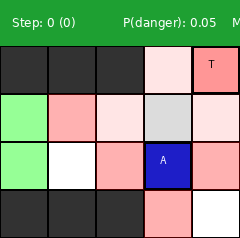

In [102]:
# BLOCK 8: save gif and print top habit policies
gif_path = "h_disc_k16_c12_075x2_d3.gif"
imageio.mimsave(gif_path, frames, fps=10)
print(f"Saved {gif_path}")
display(Image(gif_path))